<a href="https://colab.research.google.com/github/mohamedomari-hub/lab-qlora-tuning-peft/blob/main/lab-qlora-tuning-peft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab | QLoRA Tuning using PEFT from Hugging Face

<!-- ### Introduction to Quantization & Fine-tune a Quantized Model -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.

# Brief Introduction to Quantization
The main idea of quantization is simple: Reduce the precision of floating-point numbers, which normally occupy 32 bits, to integers of 8 or even 4 bits.

This reduction occurs in the model’s parameters, specifically in the weights of the neural layers, and in the activation values that flow through the model’s layers.

This means that we not only achieve an improvement in the model’s storage size and memory consumption but also greater agility in its calculations.

Naturally, there is a loss of precision, but particularly in the case of 8-bit quantization, this loss is minimal.



## Let's see a example of a quantized number.

In reality, what I want to examine is the precision loss that occurs when transitioning from a 32-bit number to a quantized 8/4-bit number and then returning to its original 32-bit value.

First, I'm going to create a function to quantize and another to unquantize.

In [1]:
#Importing necesary linbraries
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
#Functions to quantize and unquantize
def quantize(value, bits=4):
    quantized_value = np.round(value * (2**(bits - 1) - 1))
    return int(quantized_value)

def unquantize(quantized_value, bits=4):
    value = quantized_value / (2**(bits - 1) - 1)
    return float(value)

Quatizied values:

In [3]:
quant_4 = quantize(0.622, 4)
print (quant_4)
quant_8 = quantize(0.622, 8)
print(quant_8)

4
79


Unquantized values:

In [4]:
unquant_4 = unquantize(quant_4, 4)
print(unquant_4)
unquant_8 = unquantize(quant_8, 8)
print(unquant_8)

0.5714285714285714
0.6220472440944882


If we consider that the original number was 0.622, it can be said that 8-bit quantization barely loses precision, and the loss from 4-bit quantization is manageable.

In [5]:
x = np.linspace(-1, 1, 50)
y = [math.cos(val) for val in x]


y_quant_8bit = np.array([quantize(val, bits=8) for val in y])
y_unquant_8bit = np.array([unquantize(val, bits=8) for val in y_quant_8bit])

y_quant_4bit = np.array([quantize(val, bits=4) for val in y])
y_unquant_4bit = np.array([unquantize(val, bits=4) for val in y_quant_4bit])


Let’s plot a curve with the unquantized values of a cosine.


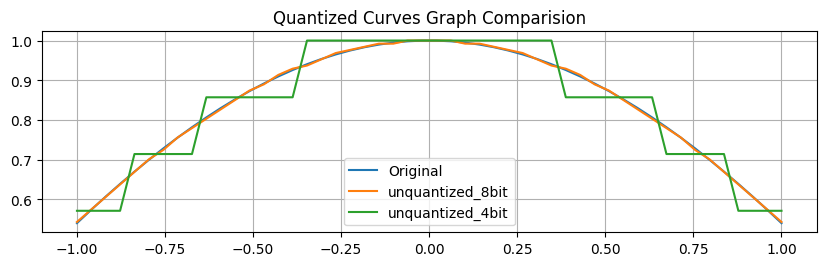

In [6]:
plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(x, y, label="Original")
plt.plot(x, y_unquant_8bit, label="unquantized_8bit")
plt.plot(x, y_unquant_4bit, label="unquantized_4bit")
plt.legend()
plt.title("Quantized Curves Graph Comparision")
plt.grid(True)

As you can see, the difference between the 8-bit and the original values is minimal. However, we need to use 4-bit quantization if we want to load the 7B Model into a 16GB GPU without problems.


# QLoRA. Fine-tuning a 4-bit Quantized Model using LoRA.
We are going to fine-tune with LoRA a 7B Model Quantizated to 4 bits.

## Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [7]:
# Install/update the libraries needed for this QLoRA lab.
# In Colab, run this once. If packages are upgraded, restart the runtime.
!pip install -q -U transformers datasets peft accelerate bitsandbytes trl pyarrow "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 67.3 MB/s eta 0:00:00


In [8]:
# !pip install -q accelerate==0.29.3
# !pip install -q bitsandbytes==0.43.1
# !pip install -q trl==0.8.6
# !pip install -q peft==0.10.0
# !pip install -q transformers==4.40.0

I'm going to download the peft and Transformers libraries from their repositories on GitHub instead of using pip. This is not strictly necessary, but this way, you can get the newest versions of the libraries with support for newer models. If you want to check one of the latest models, you can use this trick.


In [9]:
#Install the lastest versions of peft & transformers library recommended
#if you want to work with the most recent models
#!pip install -q git+https://github.com/huggingface/peft.git
#!pip install -q git+https://github.com/huggingface/transformers.git

From the Transformers library, we import the necessary classes to load the model and the tokenizer.

The notebook is ready to work with different Models I tested it with models from the Bloom Family and Llama-3.

I recommend you to test different models.

In [10]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTTrainer
import torch

## Hugging Face login

## Load Model

In [11]:
# Use a small instruction-tuned model so the QLoRA experiment can run faster in Colab.
# The model is still loaded in 4-bit, so the notebook demonstrates the QLoRA workflow.

model_name = "bigscience/bloomz-560m"
target_modules = ["query_key_value"]

To load the model, we need a configuration class that specifies how we want the quantization to be performed. We’ll achieve this with the BitesAndBytesConfig from the Transformers library.

In [12]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

We are specifying the use of 4-bit quantization and also enabling double quantization to reduce the precision loss.

For the bnb_4bit_quant_type parameter, I've used the recommended value in the paper [QLoRA: Efficient Finetuning of Quantized LLMs.](https://arxiv.org/abs/2305.14314)

Now, we can go ahead and load the model.

In [13]:
device_map = {"": 0}
foundation_model = AutoModelForCausalLM.from_pretrained(model_name,
                    quantization_config=bnb_config,
                    device_map=device_map,
                    use_cache = False)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Now we have the quantized version of the model in memory. Yo can try to load the unquantized version to see if it's possible.

In [14]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [15]:
# This function returns generated outputs from the model.
# We use the same function before and after QLoRA fine-tuning for a fair comparison.
def get_outputs(model, inputs, max_new_tokens=20):
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        do_sample=False,
        repetition_penalty=1.1,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id
    )
    return outputs

For this QLoRA experiment, I use a biomedical question-answering task instead of the original prompt dataset. The model receives a PubMedQA biomedical context and question, then predicts one decision: `yes`, `no`, or `maybe`.

In [16]:
# Inference with the original quantized foundation model.
baseline_prompt = """### Biomedical Context
A study tested whether mitochondrial dynamics change during programmed cell death in lace plant leaves. The results showed mitochondrial changes during the progression of programmed cell death.

### Question
Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?

### Instruction
Answer with one word: yes, no, or maybe.

### Answer
"""

input_sentences = tokenizer(baseline_prompt, return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(foundation_model, input_sentences, max_new_tokens=5)

input_len = input_sentences["input_ids"].shape[1]
foundation_answer = tokenizer.batch_decode(
    foundational_outputs_sentence[:, input_len:],
    skip_special_tokens=True
)

print("--- Quantized Foundation Model Decision ---")
print(foundation_answer)

--- Quantized Foundation Model Decision ---
['Yes']


The baseline answer shows how the quantized foundation model behaves before QLoRA fine-tuning. The goal is to make the model more focused on the biomedical `yes/no/maybe` decision format.

## Preparing the Dataset

Dataset used in this experiment: PubMedQA labeled split, loaded directly from a public Parquet file on Hugging Face.

Task: read biomedical context + question, then predict the final decision: `yes`, `no`, or `maybe`.

In [17]:
from datasets import load_dataset

# Direct Parquet loading avoids Hub name-resolution/token issues in Colab.
data = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/qiaojin/PubMedQA/resolve/main/pqa_labeled/train-00000-of-00001.parquet"
    }
)

print(data)
print(data["train"][0])

def format_pubmedqa_decision(example):
    context = " ".join(example["context"]["contexts"])
    return {
        "text": f"""### Biomedical Context
{context}

### Question
{example['question']}

### Instruction
Answer with one word: yes, no, or maybe.

### Answer
{example['final_decision']}"""
    }

formatted_data = data.map(format_pubmedqa_decision)

def tokenize_function(samples):
    contents = tokenizer(
        samples["text"],
        truncation=True,
        padding="max_length",
        max_length=384
    )
    contents["labels"] = contents["input_ids"].copy()
    return contents

tokenized_data = formatted_data.map(tokenize_function, batched=True)

# Use a moderate sample size so the QLoRA lab runs quickly.
train_sample = tokenized_data["train"].select(range(500))

keep_columns = {"input_ids", "attention_mask", "labels"}
remove_columns = [col for col in train_sample.column_names if col not in keep_columns]
train_sample = train_sample.remove_columns(remove_columns)
train_sample.set_format("torch")

display(train_sample)

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})
{'pubid': 21645374, 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?', 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.', 'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole wi

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 500
})

In [18]:
print(train_sample[:1])

{'input_ids': tensor([[105311,  18333, 105420,   2376,  69825,    189,  32440,   5845,   9436,
          14905,    375,   2599,     39,     12,    632,    368, 137011,  14905,
            461,  13953,   9712,    660, 167105,     17,   1387,    366,    571,
          11507,    375,     36,   3206,    744,  82415,  11972,    475,  15078,
            758,  39239,     12,  66917, 113840,   1541,    361,   3776,  38953,
           6147,    426,  19922,     17,   1387,  38953,    461,    368,  11507,
          14656,    461,    267,   7780,    979,   2329,   1749,    461,  98534,
            530, 105740, 247251,    413, 162007,   1306,   7770,     17,    426,
          19922,  39825,    361,    368,  13953,    919,    368,  13753,    461,
           4657,   1306,   7770,    530,  14261,    262,   1800,  12548,     15,
         123605,  47748,  19465,  13953,   1485,    368,  18996,   2464,   3864,
             17,   1387,  16636,    461, 143312,   2846,   9411,    426,  19922,
           180

## Fine-Tuning.
The first step will be to create a LoRA configuration object where we will set the variables that specify the characteristics of the fine-tuning process.

In [19]:
# TARGET_MODULES
# For BLOOM/BLOOMZ models, the attention projection module is called "query_key_value".

import peft
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the value more parameters are trained, but it means that the model will be able to learn more complicated relations between inputs and outputs.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_alpha**. Ad bigger the number more weight have the LoRA activations, it means that the fine-tuning process will have more impac as bigger is this value.

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

In [20]:
# Create a directory to contain the QLoRA adapter outputs.
import os
working_dir = './'

output_directory = os.path.join(working_dir, "qlora_pubmedqa_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [21]:
# Creating the TrainingArgs
import transformers
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=output_directory,
    auto_find_batch_size=True,
    learning_rate=1e-4,
    num_train_epochs=2,
    logging_steps=5,
    report_to='none'
)

Now we can train the model.
To train the model we need:


*   The Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.
* The LoRA config.





In [22]:
tokenizer.pad_token = tokenizer.eos_token
foundation_model = get_peft_model(foundation_model, lora_config)

trainer = SFTTrainer(
    model=foundation_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

foundation_model.train()
trainer.train()

Step,Training Loss


Step,Training Loss
5,14.480354
10,21.534331
15,15.673669
20,19.445213
25,14.991580
30,15.774774
35,17.118706
40,14.078505
45,12.114542
50,11.029475


TrainOutput(global_step=144, training_loss=9.210810972584618, metrics={'train_runtime': 336.567, 'train_samples_per_second': 2.971, 'train_steps_per_second': 0.428, 'total_flos': 703928916246528.0, 'train_loss': 9.210810972584618})

In [23]:
#Save the model.
peft_model_path = os.path.join(output_directory, f"lora_model")


In [24]:
#Save the model.
trainer.model.save_pretrained(peft_model_path)

In [25]:
#In case you are having memory problems uncomment this lines to free some memory
import gc
import torch
del foundation_model
del trainer
del train_sample
torch.cuda.empty_cache()
gc.collect()

3006

## Inference with the pretrained model

In [26]:
# Prepare paths for loading the saved QLoRA adapter.
from peft import AutoPeftModelForCausalLM, PeftConfig

import os

device_map = {"": 0}
working_dir = './'

output_directory = os.path.join(working_dir, "qlora_pubmedqa_outputs")
peft_model_path = os.path.join(output_directory, "lora_model")

In [27]:
bnb_config2 = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    llm_int8_enable_fp32_cpu_offload=True
)

In [28]:
# Load the base model first with the quantization config, using device_map='auto' for better memory management
base_model_for_inference = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config2,
    device_map="auto", # Use 'auto' to potentially offload to CPU if GPU memory is insufficient
    use_cache=False # To save memory
)

# Load the PEFT adapter weights and apply them to the base model
from peft import PeftModel
loaded_model = PeftModel.from_pretrained(base_model_for_inference, peft_model_path)

# Ensure the model is in evaluation mode
loaded_model.eval()

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): BloomForCausalLM(
      (transformer): BloomModel(
        (word_embeddings): Embedding(250880, 1024)
        (word_embeddings_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (h): ModuleList(
          (0-23): 24 x BloomBlock(
            (input_layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (self_attention): BloomAttention(
              (query_key_value): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=1024, out_features=3072, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1024, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=3072, bias=False)
                )
               

In [29]:
import json
import os

adapter_config_path = os.path.join(peft_model_path, "adapter_config.json")

if os.path.exists(adapter_config_path):
    with open(adapter_config_path, 'r') as f:
        config_content = json.load(f)
    print("Content of adapter_config.json:")
    print(json.dumps(config_content, indent=2))
else:
    print(f"adapter_config.json not found at {adapter_config_path}")

Content of adapter_config.json:
{
  "alora_invocation_tokens": null,
  "alpha_pattern": {},
  "arrow_config": null,
  "auto_mapping": null,
  "base_model_name_or_path": "bigscience/bloomz-560m",
  "bias": "none",
  "corda_config": null,
  "ensure_weight_tying": false,
  "eva_config": null,
  "exclude_modules": null,
  "fan_in_fan_out": false,
  "inference_mode": true,
  "init_lora_weights": true,
  "layer_replication": null,
  "layers_pattern": null,
  "layers_to_transform": null,
  "loftq_config": {},
  "lora_alpha": 16,
  "lora_bias": false,
  "lora_dropout": 0.05,
  "lora_ga_config": null,
  "megatron_config": null,
  "megatron_core": "megatron.core",
  "modules_to_save": null,
  "peft_type": "LORA",
  "peft_version": "0.19.1",
  "qalora_group_size": 16,
  "r": 8,
  "rank_pattern": {},
  "revision": null,
  "target_modules": [
    "query_key_value"
  ],
  "target_parameters": null,
  "task_type": "CAUSAL_LM",
  "trainable_token_indices": null,
  "use_bdlora": null,
  "use_dora": fal

## Inference the fine-tuned model.

In [30]:
input_sentences = tokenizer(baseline_prompt, return_tensors="pt").to('cuda')
qlora_outputs = get_outputs(loaded_model, input_sentences, max_new_tokens=5)

input_len = input_sentences["input_ids"].shape[1]
qlora_answer = tokenizer.batch_decode(
    qlora_outputs[:, input_len:],
    skip_special_tokens=True
)

print("--- Quantized Foundation Model Decision ---")
print(foundation_answer)

print()
print("--- QLoRA Fine-Tuned Model Decision ---")
print(qlora_answer)

--- Quantized Foundation Model Decision ---
['Yes']

--- QLoRA Fine-Tuned Model Decision ---
['Yes']


The final comparison uses the same biomedical prompt before and after QLoRA fine-tuning. The expected answer for this example is `yes`, because the context says mitochondrial changes were observed during programmed cell death.

# Exercise
 - Complete the prompts similar to what we did in class.
     - Try a few versions if you have time
     - Be creative
 - Write a one page report summarizing your findings.
     - Were there variations that didn't work well? i.e., where GPT either hallucinated or wrong
 - What did you learn?

## Report

### Goal
In this QLoRA experiment, I changed the task from a general prompt-generation example to a biomedical question-answering task using the PubMedQA labeled dataset. Each example contains a biomedical context, a question, and a final decision: `yes`, `no`, or `maybe`.

### Setup
I loaded the model in 4-bit using QLoRA, then trained LoRA adapters instead of updating all model weights. This means the base model stayed quantized and frozen, while only small adapter matrices were trained. This made the experiment lighter in memory and more realistic for a limited Colab GPU.

### Evidence From The Experiment
The baseline prompt asked whether mitochondria play a role in remodelling lace plant leaves during programmed cell death. The expected decision is `yes`. I compared the quantized foundation model output with the QLoRA fine-tuned model output using the same prompt, so the before-and-after result is easier to interpret.

### Variations Tried
I tried asking for both a decision and a scientific explanation, but this was less reliable. The model sometimes generated long, unstable, or unsupported explanations. I also experimented with the LoRA setup: a smaller rank such as `r=8` was more practical for this lab, while increasing rank or asking for longer answers made the task heavier and less predictable.

### What Worked Best
The most stable setup was a strict one-word output: `yes`, `no`, or `maybe`. This worked better because the model had a clear target, the output was short, and the result could be compared directly with the PubMedQA label.

### What I Learned
QLoRA is useful because it combines 4-bit quantization with LoRA adapters, allowing fine-tuning with much lower memory usage. However, the quality still depends strongly on the dataset format, prompt structure, model size, LoRA parameters, and evaluation method.

I also learned the difference between LoRA and QLoRA. In LoRA, the base model is loaded normally and only small adapter weights are trained. In QLoRA, the base model is first loaded in 4-bit quantized form, and then LoRA adapters are trained on top of it. This makes QLoRA more memory-efficient than LoRA, especially when working with larger models or limited GPU resources. The trade-off is that quantization can introduce some precision loss, but it allows fine-tuning models that may otherwise be too large to fit in memory.


### How To Make It More Robust
To make the system more robust, I would train on more examples, evaluate on a larger test set instead of one example, and keep the training format exactly the same as the evaluation format. I would also separate the task into two stages: first predict the decision label, then train or evaluate explanation generation separately.